# 11 &middot; Mass Springs: from Hooke's Law to a Sagging Cable

The spring is the simplest elastic element there is: two point masses joined by
one edge. We start from its energy, watch Hooke's law fall out of a derivative,
add inertia and compare time integrators in *phase space*, then glue many springs
into a cable and let it sag under gravity.

| step | what we do |
|---|---|
| **1** | build the spring energy and collapse the spring &mdash; Hooke's law appears |
| **2** | add mass; march Forward / Backward Euler & BDF2; read the phase portrait |
| **3** | chain springs into a cable; sag it with and without inertia |

In [1]:
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import simkit
import simkit.energies as energies
from simkit.solvers import newton_solver
import utils

## 1 &middot; The elastic energy of a single spring (Hooke's law)

A spring has endpoints $x_i$ and $x_j$. We build its energy in four small
steps, each throwing away information we do **not** want the energy to care about:

1. **edge vector** $d = x_j - x_i$ &mdash; kills *translation* (sliding both
   nodes together leaves $d$ unchanged);
2. **current length** $l = \lVert d\rVert$ &mdash; kills *rotation* (only the
   distance matters);
3. **strain** $l - l_0$ &mdash; how far we are from the rest length $l_0$;
4. **energy** $\psi = \tfrac{1}{2}\,k\,(l-l_0)^2$.

The stiffness is $k = ym/l_0^2$; dividing by $l_0^2$ makes the energy
mesh-independent. This $\psi$ is exactly `mass_springs_energy_element_d`.
Differentiate once and the **force** drops out,

$$
f = -\frac{d\psi}{dl} = -k\,(l-l_0),
$$

linear in the stretch and pointing back toward rest &mdash; that *is* Hooke's law,
derived from a quadratic energy rather than assumed.

rest length l0 = 1.000,  stiffness k = ym/l0^2 = 1.000


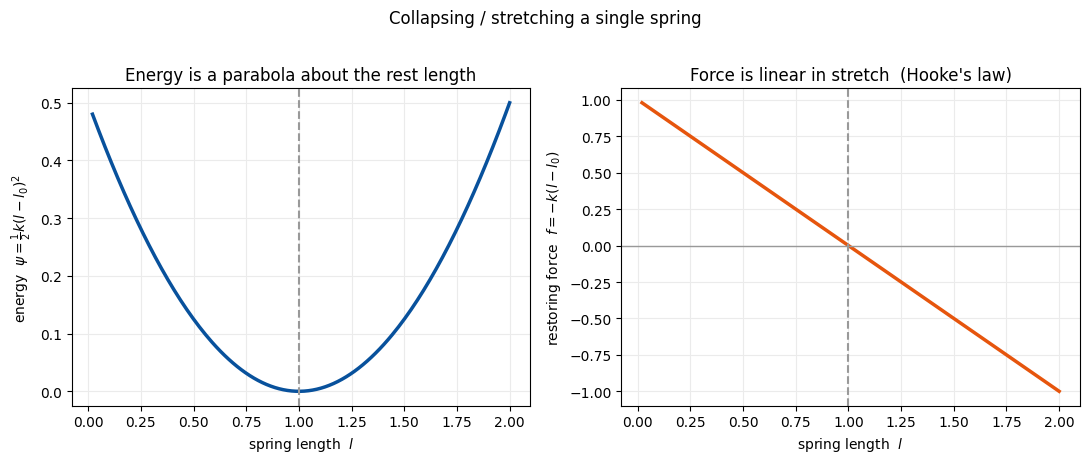

In [2]:
l0_val = 1.0
X = np.array([[0.0, 0.0], [l0_val, 0.0]])     # node 0 pinned at origin, node 1 at rest
E = np.array([[0, 1]])

ym  = np.array([[1.0]])                        # per-edge stiffness
vol = np.ones((1, 1))                          # one element, unit quadrature weight
l0  = simkit.edge_lengths(X, E).reshape(-1, 1)
k   = float((ym / l0 ** 2).flatten()[0])       # effective Hooke stiffness
print(f"rest length l0 = {l0[0,0]:.3f},  stiffness k = ym/l0^2 = {k:.3f}")

# energy + force as the spring is collapsed (l -> 0) and stretched (l -> 2 l0)
lengths = np.linspace(0.02, 2.0 * l0_val, 200)
d       = np.column_stack([lengths, np.zeros_like(lengths)])
psi     = energies.mass_springs_energy_element_d(d, ym, l0).flatten()
dpsi_dl = energies.mass_springs_gradient_element_d(d, ym, l0)[:, 0]   # = k (l - l0)
force   = -dpsi_dl                                                     # Hooke restoring force

fig, (ax_e, ax_f) = plt.subplots(1, 2, figsize=(11, 4.5))
ax_e.plot(lengths, psi, color=utils.SPRING_EDGE, lw=2.5)
ax_e.axvline(l0_val, color="0.6", ls="--", lw=1.5)
ax_e.set_xlabel("spring length  $l$"); ax_e.set_ylabel(r"energy  $\psi=\frac{1}{2}k(l-l_0)^2$")
ax_e.set_title("Energy is a parabola about the rest length"); ax_e.grid(True, color="0.92")
ax_f.plot(lengths, force, color=utils.SPRING_NODE, lw=2.5)
ax_f.axhline(0, color="0.6", lw=1.0); ax_f.axvline(l0_val, color="0.6", ls="--", lw=1.5)
ax_f.set_xlabel("spring length  $l$"); ax_f.set_ylabel(r"restoring force  $f=-k(l-l_0)$")
ax_f.set_title("Force is linear in stretch  (Hooke's law)"); ax_f.grid(True, color="0.92")
fig.suptitle("Collapsing / stretching a single spring", y=1.02); fig.tight_layout(); plt.show()

Now collapse and re-stretch the spring, revealing the energy curve in lock-step
so the quadratic well around $l_0$ is unmistakable.

In [3]:
sweep = np.concatenate([np.linspace(0.1, 1.9, 45), np.linspace(1.9, 0.1, 45)])

# build each frame's spring state with an explicit loop
states = []
for s in sweep:
    states.append(np.array([[0.0, 0.0], [s, 0.0]]))

psi_sweep = energies.mass_springs_energy_element_d(
    np.column_stack([sweep, np.zeros_like(sweep)]), ym, l0).flatten()

fig, anim = utils.animate_springs_energy(
    states, E, sweep, {"elastic": psi_sweep}, rest=X, lims=((-0.4, 2.2), (-1.0, 1.0)),
    xlabel="spring length  $l$", ylabel="elastic energy", scene_title="spring (gray = rest)",
    title="energy vs length", colors={"elastic": utils.SPRING_EDGE}, pin_pts=X[:1])
utils.show_video(fig, anim, "media/11_spring_collapse.mp4", fps=20)

## 2 &middot; Adding inertia: integrators and the phase portrait

Now give the free node mass $m$ and let it move. With displacement-from-rest
$u = q - l_0$, Newton's second law is a harmonic oscillator,

$$
m\,\ddot u = -k\,u, \qquad \omega = \sqrt{k/m}.
$$

Writing the state $y = [u, v]$ (velocity $v=\dot u$) gives $y' = A y$
with $A = \begin{pmatrix}0 & 1\\ -k/m & 0\end{pmatrix}$. The exact motion
conserves $H = \tfrac12 k u^2 + \tfrac12 m v^2$, so in the
position&ndash;momentum plane $(q,\,p=mv)$ it traces a **closed ellipse**
forever. A good integrator keeps that loop closed:

| scheme | one step | phase-space behaviour |
|---|---|---|
| **Forward Euler** | $y_{n+1} = (I + hA)\,y_n$ | spirals **outward** (gains energy) |
| **Backward Euler** | $(I - hA)\,y_{n+1} = y_n$ | spirals **inward** (numerical damping) |
| **BDF2** | $(3I - 2hA)\,y_{n+1} = 4y_n - y_{n-1}$ | **nearly closed** (2nd order) |

In [4]:
k, m = 1.0, 1.0                       # stiffness (= ym/l0^2 from section 1) and mass
A = np.array([[0.0, 1.0], [-k / m, 0.0]])
omega = np.sqrt(k / m); period = 2 * np.pi / omega; I2 = np.eye(2)
print(f"omega = {omega:.3f},  period = {period:.3f}")

# the three integrators as analytic 2x2 maps on the state y = [u, v]
fe_step   = lambda y, h:      (I2 + h * A) @ y                                  # Forward Euler
be_step   = lambda y, h:      np.linalg.solve(I2 - h * A, y)                    # Backward Euler
bdf2_step = lambda y, yp, h:  np.linalg.solve(3 * I2 - 2 * h * A, 4 * y - yp)   # BDF2

def integrate(kind, h, n_steps, y0):
    """Roll the chosen scheme forward and return (position, momentum) and energy."""
    ys = [y0.copy()]
    if kind == "Forward Euler":
        for _ in range(n_steps):
            ys.append(fe_step(ys[-1], h))
    elif kind == "Backward Euler":
        for _ in range(n_steps):
            ys.append(be_step(ys[-1], h))
    else:                                       # BDF2, bootstrapped with one BE step
        ys.append(be_step(ys[0], h))
        for _ in range(2, n_steps + 1):
            ys.append(bdf2_step(ys[-1], ys[-2], h))
    Y = np.array(ys); u, v = Y[:, 0], Y[:, 1]
    qp = np.column_stack([u, m * v])            # (position, momentum)
    H  = 0.5 * k * u ** 2 + 0.5 * m * v ** 2    # total energy
    return qp, H

y0 = np.array([1.0, 0.0])            # displaced and at rest
h  = 0.1                             # coarse step so the schemes visibly differ
n_steps = int(round(3 * period / h)) # ~3 oscillations
schemes = ["Forward Euler", "Backward Euler", "BDF2"]

# run each scheme explicitly
traj = {}
for s in schemes:
    traj[s] = integrate(s, h, n_steps, y0)

omega = 1.000,  period = 6.283


### The phase portrait

Position vs momentum. Forward Euler spirals **out**, Backward Euler spirals
**in**, and BDF2 sits right on the exact energy-conserving ellipse.

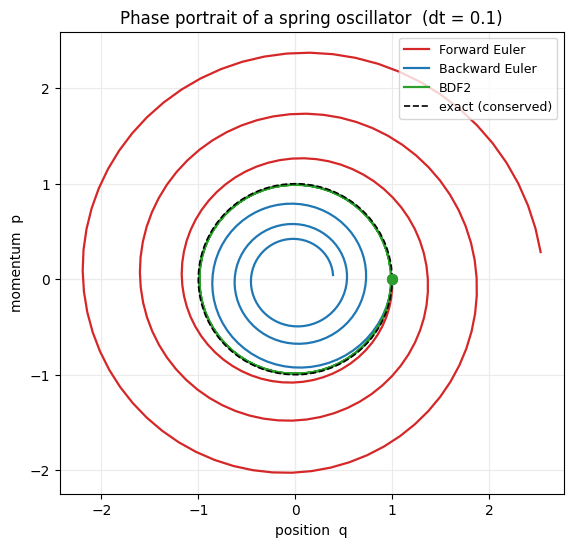

In [5]:
fig, ax = utils.phase_plot({s: traj[s][0] for s in schemes},
                           title=f"Phase portrait of a spring oscillator  (dt = {h})")
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(theta), m * omega * np.sin(theta), "k--", lw=1.2, label="exact (conserved)")
ax.legend(loc="upper right", fontsize=9); plt.show()

Same story as a time series: the total energy each scheme *should* hold flat.

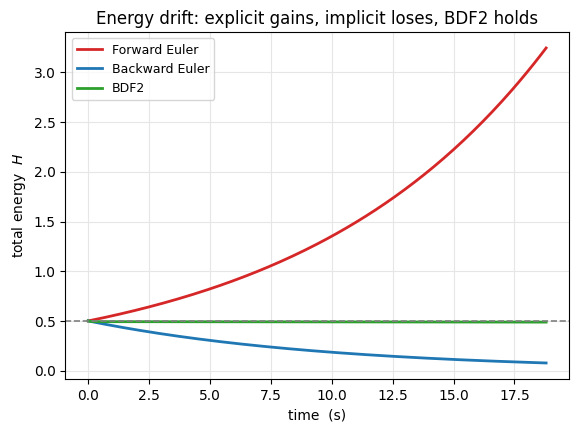

In [6]:
t = np.arange(n_steps + 1) * h
fig, ax = utils.line_plot(t, {s: traj[s][1] for s in schemes},
    xlabel="time  (s)", ylabel="total energy  $H$", colors=utils.INTEGRATOR_COLORS,
    title="Energy drift: explicit gains, implicit loses, BDF2 holds")
ax.axhline(0.5 * k * y0[0] ** 2, color="0.5", ls="--", lw=1.2); plt.show()

And the same three integrators as actual oscillating springs, side by side.

In [7]:
E = np.array([[0, 1]])
stride = max(1, (n_steps + 1) // 90)

# build one panel of spring states per scheme with an explicit loop
panels = []
for s in schemes:
    u = traj[s][0][::stride, 0]
    states = []
    for ui in u:
        states.append(np.array([[0.0, 0.0], [1.0 + ui, 0.0]]))
    panels.append({"states": states, "E": E, "title": s})

fig, anim = utils.animate_springs_grid(panels, lims=((-0.6, 3.2), (-1.0, 1.0)), fps=20,
    pin_pts=np.array([[0.0, 0.0]]),
    suptitle="Same spring, same dt: explicit grows, implicit shrinks, BDF2 steady")
utils.show_video(fig, anim, "media/11_oscillators.mp4", fps=20)

## 3 &middot; A cable: many spring elements glued together

One spring resists only *stretch*. Chain many end to end and pin both ends, and
the assembly behaves like an elastic **cable**: under gravity the interior nodes
drop until tension balances weight (a catenary sag). Pure springs carry no
*bending* stiffness, so this is a cable, not a stiff beam &mdash; bending would be
the next ingredient.

With flattened vertex positions $x$ the total potential is

$$
\Phi(x) = \underbrace{\textstyle\sum_e \mathrm{vol}_e\,\psi_e(x)}_{\text{elastic}}
   \;-\; \underbrace{f_g^\top x}_{\text{gravity}}
   \;+\; \underbrace{\tfrac12 x^\top Q x + b^\top x}_{\text{pin penalty}}.
$$

simkit assembles the elastic term with the edge-displacement operator $J$
(so $d = Jx$ stacks every edge vector) via `mass_springs_*_z`.

* **Without inertia** (quasi-static): the cable sits where $\Phi$ is
  *minimised*; hand $\Phi, \nabla\Phi, \nabla^2\Phi$ to Newton.
* **With inertia** (dynamic): each Backward-Euler step minimises
  $\Phi(x) + \tfrac{1}{2h^2}\lVert x - \tilde x\rVert_M^2$ with momentum
  target $\tilde x = x_n + h v_n$; the cable overshoots and rings down to the
  *same* equilibrium.

### The cable simulator

`CableSim` composes the cable's terms from `utils` &mdash; the spring elastic
energy, both endpoint pins, and gravity. Its `energy / gradient / hessian` are
the **static** potential $\Phi$, summed **one term per line** exactly as Newton
wants. A separate `step()` adds the Backward-Euler inertia term (its own line)
and does one implicit solve, so the same potential drives both the quasi-static
and the dynamic runs.

In [8]:
class CableSim:
    """Horizontal chain of springs pinned at both ends, sagging under gravity."""

    def __init__(self, n_nodes=21, length=4.0, ym_val=40.0, rho=1.0, h=0.04):
        X = np.zeros((n_nodes, 2)); X[:, 0] = np.linspace(0.0, length, n_nodes)
        E = np.array([[i, i + 1] for i in range(n_nodes - 1)])
        n, dim = X.shape

        Be = simkit.edge_displacement_jacobian(X, E)
        J  = sp.sparse.kron(Be, sp.sparse.eye(dim)).tocsc()       # d = J x stacks edge vectors
        l0 = simkit.edge_lengths(X, E).reshape(-1, 1)
        ym = np.full((E.shape[0], 1), ym_val); vol = np.ones((E.shape[0], 1))

        self.spring  = utils.SpringEnergy(J, ym, vol, l0)
        self.M       = sp.sparse.kron(simkit.massmatrix(X, E, rho=rho), sp.sparse.eye(dim)).tocsc()
        self.gravity = utils.Gravity(simkit.gravity_force(X, E, a=-9.8, rho=rho).reshape(-1, 1))
        self.pin     = utils.PenaltySpring(X.shape[0], dim, 1e8).set([0, n_nodes - 1], X[[0, n_nodes - 1]])
        self.inertia = utils.Inertia(self.M, h)

        self.X, self.E, self.n, self.dim = X, E, n, dim
        self.pin_idx = np.array([0, n_nodes - 1])

    # ---- static potential Phi(x) = spring + pin + gravity (one term per line) ----
    def energy(self, x):
        E_spring  = self.spring.energy(x)
        E_pin     = self.pin.energy(x)
        E_gravity = self.gravity.energy(x)
        return E_spring + E_pin + E_gravity

    def gradient(self, x):
        g_spring  = self.spring.gradient(x)
        g_pin     = self.pin.gradient(x)
        g_gravity = self.gravity.gradient(x)
        return g_spring + g_pin + g_gravity

    def hessian(self, x):
        H_spring = self.spring.hessian(x)
        H_pin    = self.pin.hessian(x)
        return H_spring + H_pin       # gravity is linear: no Hessian term

    # ---- one Backward-Euler step: static potential + inertia term ----
    def step(self, x_n, v_n):
        self.inertia.update(x_n, v_n)

        def energy(x):
            E_static  = self.energy(x)
            E_inertia = self.inertia.energy(x)
            return E_static + E_inertia

        def gradient(x):
            g_static  = self.gradient(x)
            g_inertia = self.inertia.gradient(x)
            return g_static + g_inertia

        def hessian(x):
            H_static  = self.hessian(x)
            H_inertia = self.inertia.hessian(x)
            return H_static + H_inertia

        x0 = x_n + self.inertia.h * v_n      # inertial guess = momentum target
        x_next = newton_solver(x0, energy, gradient, hessian, max_iter=20, do_line_search=True)
        v_next = (x_next - x_n) / self.inertia.h
        return x_next, v_next

cable = CableSim()
X, E = cable.X, cable.E
n, dim = cable.n, cable.dim

### Without inertia: static equilibrium via Newton

No time, no velocity &mdash; just minimise $\Phi$. We record every Newton
iterate and watch the flat chain relax into its catenary sag.

In [9]:
# explicit Newton loop, recording every iterate
static_states = [X.copy()]
x = X.flatten().astype(float).reshape(-1, 1)
for _ in range(40):
    x = newton_solver(x, cable.energy, cable.gradient, cable.hessian, max_iter=1, do_line_search=True)
    static_states.append(x.reshape(n, dim).copy())
x_static = x.reshape(n, dim)
print(f"static: |grad| = {np.linalg.norm(cable.gradient(x_static.flatten().reshape(-1, 1))):.2e},  "
      f"max sag = {-(x_static[:,1].min()):.3f}")

fig, anim = utils.animate_springs_energy(
    static_states, E, np.arange(len(static_states)),
    {"potential": [cable.energy(s.flatten().reshape(-1, 1)) for s in static_states]}, rest=X,
    lims=((-0.5, 4.5), (-2.6, 0.6)), xlabel="Newton iteration", ylabel="potential energy",
    scene_title="static sag (gray = rest)", title="energy minimised",
    colors={"potential": utils.ENERGY_COLORS["potential"]}, pin_pts=X[cable.pin_idx])
utils.show_video(fig, anim, "media/11_cable_static.mp4", fps=12)

static: |grad| = 3.60e-08,  max sag = 0.883


### With inertia: Backward-Euler dynamics from rest

Release the flat chain and march it in time. It falls, overshoots, and oscillates
&mdash; the kinetic energy rings down as it settles to the static shape above.

In [10]:
n_steps = 150

# explicit dynamic loop from rest, recording kinetic energy each step
U = X.flatten().astype(float).reshape(-1, 1)
V = np.zeros_like(U)
dyn_states, ke_hist, t_hist = [X.copy()], [0.0], [0.0]
for step in range(n_steps):
    U, V = cable.step(U, V)
    dyn_states.append(U.reshape(n, dim).copy())
    ke_hist.append(0.5 * (V.T @ (cable.M @ V))[0, 0])
    t_hist.append((step + 1) * cable.inertia.h)
print(f"dynamic: settled max sag = {-(U.reshape(n, dim)[:,1].min()):.3f}  (matches static),  "
      f"final KE = {ke_hist[-1]:.2e}")

fig, anim = utils.animate_springs_energy(
    dyn_states, E, t_hist, {"kinetic": ke_hist}, rest=X, lims=((-0.5, 4.5), (-2.6, 0.6)),
    xlabel="time  (s)", ylabel="kinetic energy", scene_title="dynamic sag (Backward Euler)",
    title="kinetic energy rings down", colors={"kinetic": utils.ENERGY_COLORS["kinetic"]},
    pin_pts=X[cable.pin_idx])
utils.show_video(fig, anim, "media/11_cable_dynamic.mp4", fps=25)

dynamic: settled max sag = 0.893  (matches static),  final KE = 2.97e-04


### Same equilibrium, two roads

Quasi-static minimisation and full dynamics settle to the **same** sagged shape.

In [11]:
nf = 80

# resample both runs to nf frames with explicit loops
qs = []
for i in range(nf):
    j = min(int(i / nf * (len(static_states) - 1)), len(static_states) - 1)
    qs.append(static_states[j])

dyn = []
for i in np.linspace(0, len(dyn_states) - 1, nf).astype(int):
    dyn.append(dyn_states[i])

fig, anim = utils.animate_springs_grid(
    [{"states": qs,  "E": E, "title": "without inertia (quasi-static)"},
     {"states": dyn, "E": E, "title": "with inertia (dynamic)"}],
    lims=((-0.5, 4.5), (-2.6, 0.6)), fps=25, pin_pts=X[cable.pin_idx],
    suptitle="Cable sag: minimisation vs dynamics settle to the same shape")
utils.show_video(fig, anim, "media/11_cable_compare.mp4", fps=25)

Finally, a quick parameter study: softer springs (smaller `ym`) sag more.

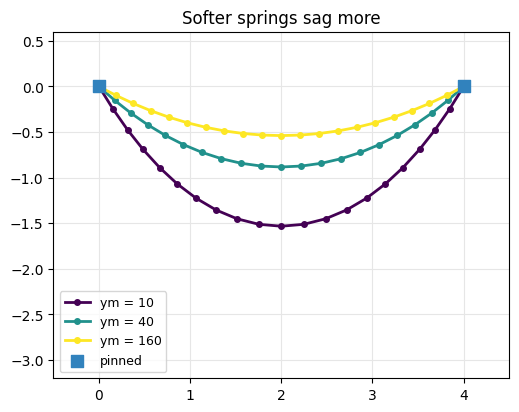

In [12]:
# explicit stiffness sweep: fresh CableSim + static solve per material
sags = {}
for ym_val in [10.0, 40.0, 160.0]:
    cc = CableSim(ym_val=ym_val)
    x0 = cc.X.flatten().astype(float).reshape(-1, 1)
    xs = newton_solver(x0, cc.energy, cc.gradient, cc.hessian, max_iter=60, do_line_search=True)
    sags[ym_val] = xs.reshape(cc.n, cc.dim)

fig, ax = plt.subplots(figsize=(7, 4.5))
utils.setup_axes(ax, (-0.5, 4.5), (-3.2, 0.6), title="Softer springs sag more")
cmap = plt.get_cmap("viridis")
for j, (ym_val, xs) in enumerate(sags.items()):
    ax.plot(xs[:, 0], xs[:, 1], "-o", ms=4, lw=2,
            color=cmap(j / max(1, len(sags) - 1)), label=f"ym = {ym_val:g}")
ax.scatter(X[cable.pin_idx, 0], X[cable.pin_idx, 1], s=70, marker="s",
           color=utils.PIN_C, zorder=5, label="pinned")
ax.legend(fontsize=9); plt.show()

### Takeaways
* A spring stores $\tfrac12 k (l-l_0)^2$; differentiating gives the linear
  **Hooke force** $-k(l-l_0)$.
* With inertia the integrator decides the energy behaviour: **Forward Euler**
  gains it (unstable), **Backward Euler** bleeds it (damped), **BDF2** nearly
  conserves it &mdash; vivid in the phase portrait.
* Many springs make an elastic **cable**; gravity sags it into a catenary, and the
  quasi-static minimisation and the dynamic Backward-Euler run settle to the
  **same** equilibrium shape.